# Lab - feature importance

1. Use the **load_wine** data (remember to split your data into a train and a test set). Go through the steps in the previous slides to find the most important features. Then refit a tree on the top features only: is it as good as the tree that uses all features?

**See slides for more details!**

In [31]:
import pandas as pd

from sklearn import tree
from matplotlib import pyplot as plt
from sklearn.datasets import load_wine
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split

wine_data = load_wine(as_frame = True)

df = wine_data.frame.dropna()

y = df["target"]
X = df.drop(["target"], axis = 1)

display(X)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)
print(f"X_train {X_train.shape}, X_test {X_test.shape}, y_train {y_train.shape}, y_test {y_test.shape}")

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0


X_train (142, 13), X_test (36, 13), y_train (142,), y_test (36,)


In [8]:
dt = tree.DecisionTreeClassifier(random_state = 42).fit(X = X_train, y = y_train)

y_test_hat = dt.predict(X = X_test)

accuracy = accuracy_score(y_true = y_test, y_pred = y_test_hat)
print(f"DT with default settings achieved {round(accuracy * 100, 1)}% accuracy.")

DT with default settings achieved 94.4% accuracy.


In [14]:
feature_importance = pd.DataFrame(zip(dt.feature_names_in_, dt.feature_importances_), columns = ["Feature", "Importance"])
feature_importance = feature_importance.sort_values("Importance", ascending = False).reset_index(drop = True)

display(feature_importance[:10])

,Feature,Importance
0,flavanoids,0.411053
1,color_intensity,0.384934
2,proline,0.164075
3,ash,0.020942
4,alcohol,0.018995
5,magnesium,0.000000
6,alcalinity_of_ash,0.000000
7,malic_acid,0.000000
8,total_phenols,0.000000
9,proanthocyanins,0.000000


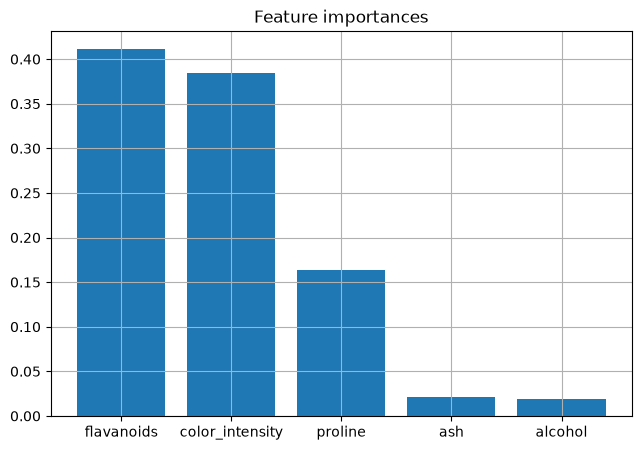

In [21]:
fig = plt.figure(figsize = [7.5, 5])

plt.title("Feature importances")
plt.bar(feature_importance["Feature"][:5], feature_importance["Importance"][:5])

plt.grid()
plt.show()

In [43]:
# Selecting the firsts five features for training another model
top_features = (feature_importance["Feature"]).argsort()[:5]
top_features_names = [dt.feature_names_in_[i] for i in top_features]
print(f"Top 5 features: {top_features_names}")

Z_train = X_train[top_features_names]
Z_test = X_test[top_features_names]

dt_top = tree.DecisionTreeClassifier(random_state = 42).fit(X = Z_train, y = y_train)

y_test_hat_top = dt_top.predict(X = Z_test)

accuracy_top = accuracy_score(y_true = y_test, y_pred = y_test_hat_top)
print(f"DT with only the top features achieved {round(accuracy_top * 100, 1)}% accuracy.")

Top 5 features: ['flavanoids', 'magnesium', 'alcalinity_of_ash', 'malic_acid', 'alcohol']
DT with only the top features achieved 91.7% accuracy.


Also the random_state so the seed can influence the final results of our model. 

We cannot arrive to one perfect tree, the main thing is just to attempt with different combinations of data.